In [6]:
# Import PySpark
from pyspark.sql import SparkSession
# Create a SparkSession
spark = SparkSession.builder \
    .appName("PySpark-Get-Started") \
    .getOrCreate()

### 1. Load and prepare the dataset. 

* The location of the data is: 
```shell
./data/rating/
```
* There are four csv files:
    * rating.csv
    * links.csv
    * movies.csv
    * tags.csv 
* Using these files build a dataset of the following structure:
    * movieId
    * title
    * genres
    * userId
    * rating 
    * tags 
    * review_timestamp
    * imdbId
    * tmdbId


In [7]:
# Load the synthetic data into a DataFrame
data_file_path1 = "data/rating/movies.csv"
df1 = spark.read.csv(data_file_path1, header=True, inferSchema=True)
data_file_path2 = "data/rating/ratings.csv"
df2 = spark.read.csv(data_file_path2, header=True, inferSchema=True)
data_file_path3 = "data/rating/links.csv"
df3 = spark.read.csv(data_file_path3, header=True, inferSchema=True)
data_file_path4 = "data/rating/tags.csv"
df4 = spark.read.csv(data_file_path4, header=True, inferSchema=True)

In [8]:
# Display schema of DataFrame
df1.printSchema()
# Show the initial DataFrame
print("Initial DataFrame:")
df1.show(10)


# Show the initial DataFrame
df2.printSchema()
print("Initial DataFrame:")
df2.show(10)

# Show the initial DataFrame
df3.printSchema()
print("Initial DataFrame:")
df3.show(10)

# Show the initial DataFrame
df4.printSchema()
print("Initial DataFrame:")
df4.show(10)

root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

Initial DataFrame:
+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
|      6|         Heat (1995)|Action|Crime|Thri...|
|      7|      Sabrina (1995)|      Comedy|Romance|
|      8| Tom and Huck (1995)|  Adventure|Children|
|      9| Sudden Death (1995)|              Action|
|     10|    GoldenEye (1995)|Action|Adventure|...|
+-------+--------------------+--------------------+
only showing top 10 rows

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (n

In [10]:
inner_df=df1.join(df2,df1.movieId==df2.movieId).drop(df2.movieId)

In [33]:
--inner_df=inner_df.drop("timestamp")

In [11]:
inner_df.show()

+-------+--------------------+--------------------+------+------+---------+
|movieId|               title|              genres|userId|rating|timestamp|
+-------+--------------------+--------------------+------+------+---------+
|      1|    Toy Story (1995)|Adventure|Animati...|     1|   4.0|964982703|
|      3|Grumpier Old Men ...|      Comedy|Romance|     1|   4.0|964981247|
|      6|         Heat (1995)|Action|Crime|Thri...|     1|   4.0|964982224|
|     47|Seven (a.k.a. Se7...|    Mystery|Thriller|     1|   5.0|964983815|
|     50|Usual Suspects, T...|Crime|Mystery|Thr...|     1|   5.0|964982931|
|     70|From Dusk Till Da...|Action|Comedy|Hor...|     1|   3.0|964982400|
|    101|Bottle Rocket (1996)|Adventure|Comedy|...|     1|   5.0|964980868|
|    110|   Braveheart (1995)|    Action|Drama|War|     1|   4.0|964982176|
|    151|      Rob Roy (1995)|Action|Drama|Roma...|     1|   5.0|964984041|
|    157|Canadian Bacon (1...|          Comedy|War|     1|   5.0|964984100|
|    163|   

In [12]:
inner_df2=inner_df.join(df3,df3.movieId==inner_df.movieId).drop(inner_df.movieId)

In [13]:
inner_df3=inner_df2.join(df4,inner_df2.movieId==df4.movieId).drop(df4.movieId).drop(df4.timestamp).drop(df4.userId)

In [14]:
inner_df3.show()

+--------------------+--------------------+------+------+---------+-------+------+------+---------------+
|               title|              genres|userId|rating|timestamp|movieId|imdbId|tmdbId|            tag|
+--------------------+--------------------+------+------+---------+-------+------+------+---------------+
|    Toy Story (1995)|Adventure|Animati...|     1|   4.0|964982703|      1|114709|   862|            fun|
|    Toy Story (1995)|Adventure|Animati...|     1|   4.0|964982703|      1|114709|   862|          pixar|
|    Toy Story (1995)|Adventure|Animati...|     1|   4.0|964982703|      1|114709|   862|          pixar|
|Grumpier Old Men ...|      Comedy|Romance|     1|   4.0|964981247|      3|113228| 15602|            old|
|Grumpier Old Men ...|      Comedy|Romance|     1|   4.0|964981247|      3|113228| 15602|          moldy|
|Seven (a.k.a. Se7...|    Mystery|Thriller|     1|   5.0|964983815|     47|114369|   807|  serial killer|
|Seven (a.k.a. Se7...|    Mystery|Thriller|   

### 2. Create a table view where you show the following information:
* Title
* Genres 
* Avg. Rating
* Max Rating
* Min Rating
* Number of reviews
* IMDB Link (full link)

In [15]:
import pyspark.sql.functions as F

In [16]:
inner_df3.createOrReplaceTempView('movie')


In [17]:
final_table=spark.sql("""
--CREATE OR REPLACE VIEW movie_view AS
WITH t AS (
    SELECT title, genres, rating, imdbId
    FROM movie
),
t2 AS (
    SELECT 
        title,
        genres,
        imdbId,
        AVG(rating) AS avgr,
        MAX(rating) AS maxr,
        MIN(rating) AS minr,
        COUNT(*) AS numuser
    FROM t
    GROUP BY title, genres, imdbId
)
SELECT 
    title,
    genres,
    avgr,
    maxr,
    minr,
    numuser,
    CONCAT('https://www.imdb.com/title/tt', imdbId) AS imdb_link
FROM t2
""")                                                              
 


In [18]:
final_table.createOrReplaceTempView("movie_view")

In [19]:
final_table.show()

+--------------------+--------------------+------------------+----+----+-------+--------------------+
|               title|              genres|              avgr|maxr|minr|numuser|           imdb_link|
+--------------------+--------------------+------------------+----+----+-------+--------------------+
|Kill Bill: Vol. 1...|Action|Crime|Thri...|3.9618320610687023| 5.0| 0.5|    262|https://www.imdb....|
|When Harry Met Sa...|      Comedy|Romance|3.8588235294117648| 5.0| 1.5|     85|https://www.imdb....|
|Man on the Moon (...|        Comedy|Drama|3.4871794871794872| 5.0| 1.0|     39|https://www.imdb....|
|Paradise Lost: Th...|         Documentary| 4.083333333333333| 5.0| 3.0|      6|https://www.imdb....|
|Hurt Locker, The ...|Action|Drama|Thri...|4.0588235294117645| 5.0| 1.0|     34|https://www.imdb....|
|   Stage Door (1937)|               Drama| 4.166666666666667| 4.5| 4.0|      3|https://www.imdb....|
|Riding Giants (2004)|         Documentary|               4.0| 4.5| 3.0|      4|ht

### 3. Create a wordclouds for movies and generes.   

#### Notes:
* You can you Dataframe or RDD to solve the tasks. 
* You can use this notebook directly or write your code in python, R, java, or Scala and submit jobs to spark.  
* All libraries needed to work with python or jupyter notebook to solve the tasks are pre-installed, however, if you wish you different programing language, or some other library you need to install it yourself. 
* The Dockerfile for this container is provided, you can modify it on your own, or you could install evering directly on your machine if you don't wish to use docker.    

In [80]:
movie =spark.sql(""" select  title , count(*)as freq_movie from movie_view group by title""")


In [81]:
movie_pd = movie.toPandas()

In [83]:
movie_pd

,title,freq_movie
0,Snow White and the Seven Dwarfs (1937),1
1,"Hello, Dolly! (1969)",1
2,In the Heat of the Night (1967),1
3,Love Story (1970),1
4,Elizabeth (1998),1
...,...,...
1549,Chariots of Fire (1981),1
1550,Ghost World (2001),1
1551,13 Going on 30 (2004),1
1552,Tupac: Resurrection (2003),1


In [82]:
movie_pd['title'].value_counts()['Toy Story (1995)']

1

In [84]:
movie_pd.columns

Index(['title', 'freq_movie'], dtype='object')

In [21]:
movie_pd = final_table.toPandas()

In [22]:
df_final=dict(zip(movie_pd['title'],movie_pd['numuser']))

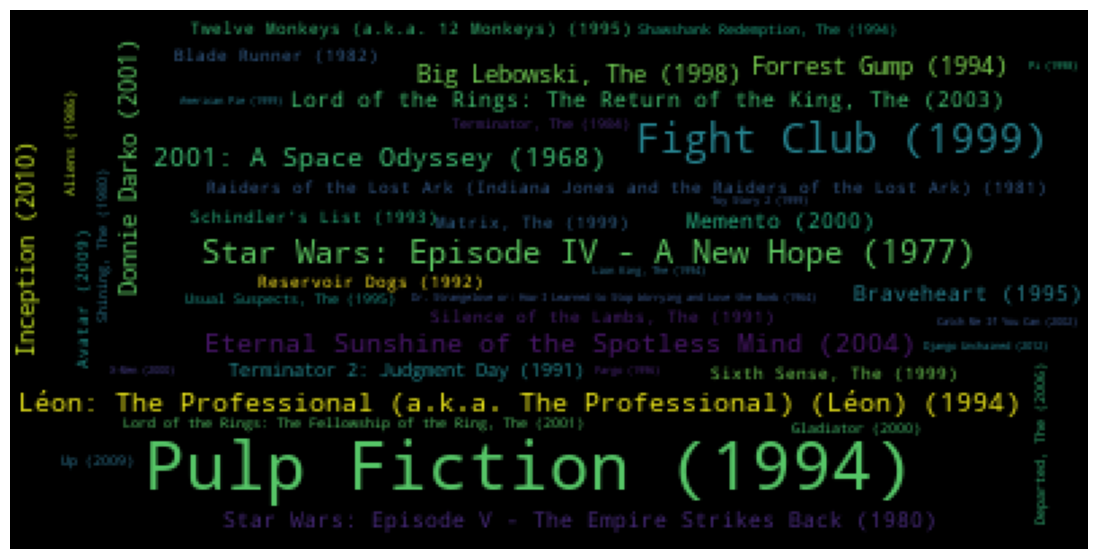

In [23]:
from  wordcloud import WordCloud 
import matplotlib.pyplot as plt 
wc = WordCloud()
wc.generate_from_frequencies(df_final)
plt.figure(figsize=(15, 7))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [27]:
movie_pd['title'].head(20)

0                              Kill Bill: Vol. 1 (2003)
1                        When Harry Met Sally... (1989)
2                                Man on the Moon (1999)
3     Paradise Lost: The Child Murders at Robin Hood...
4                               Hurt Locker, The (2008)
5                                     Stage Door (1937)
6                                  Riding Giants (2004)
7                     "11'09""01 - September 11 (2002)"
8                       Who Framed Roger Rabbit? (1988)
9                               Corrina, Corrina (1994)
10                          Beauty and the Beast (1991)
11                                Lion King, The (1994)
12                              Don Juan DeMarco (1995)
13               Wallace & Gromit: A Close Shave (1995)
14                                       Sabrina (1954)
15                               In Love and War (1996)
16                           Friendly Persuasion (1956)
17                                         Alien

In [28]:

# 
max_idx = movie_pd['numuser'].idxmax()
movie_pd.loc[max_idx, ['title','numuser']]

title      Pulp Fiction (1994)
numuser                  55567
Name: 549, dtype: object

In [32]:
from pyspark.sql.functions import split, explode, col
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Explode genres into separate rows
df_genres = final_table.select(explode(split(col("genres"), "\|")).alias("genre"))
df_genres.show(20, truncate=False)

+-----------+
|genre      |
+-----------+
|Action     |
|Crime      |
|Thriller   |
|Comedy     |
|Romance    |
|Comedy     |
|Drama      |
|Documentary|
|Action     |
|Drama      |
|Thriller   |
|War        |
|Drama      |
|Documentary|
|Drama      |
|Adventure  |
|Animation  |
|Children   |
|Comedy     |
|Crime      |
+-----------+
only showing top 20 rows



In [36]:
# 2. Count occurrences of each genre
df_genre_counts = df_genres.groupBy("genre").count()
df_genre_counts.show(50, truncate=False)

+------------------+-----+
|genre             |count|
+------------------+-----+
|Crime             |204  |
|Romance           |342  |
|Thriller          |292  |
|Adventure         |216  |
|Drama             |872  |
|War               |76   |
|Documentary       |66   |
|Fantasy           |119  |
|Mystery           |131  |
|Musical           |84   |
|Animation         |85   |
|Film-Noir         |33   |
|(no genres listed)|1    |
|IMAX              |30   |
|Horror            |90   |
|Western           |25   |
|Comedy            |516  |
|Children          |93   |
|Action            |235  |
|Sci-Fi            |160  |
+------------------+-----+



In [37]:
df_genre_counts_pd = df_genre_counts.toPandas()
df_genre_counts_pd

,genre,count
0,Crime,204
1,Romance,342
2,Thriller,292
3,Adventure,216
4,Drama,872
5,War,76
6,Documentary,66
7,Fantasy,119
8,Mystery,131
9,Musical,84


In [38]:
# 3. Convert to Pandas for WordCloud
genre_dict = dict(zip(genre_pd['genre'], genre_pd['count']))
print(genre_dict)

{'Crime': 204, 'Romance': 342, 'Thriller': 292, 'Adventure': 216, 'Drama': 872, 'War': 76, 'Documentary': 66, 'Fantasy': 119, 'Mystery': 131, 'Musical': 84, 'Animation': 85, 'Film-Noir': 33, '(no genres listed)': 1, 'IMAX': 30, 'Horror': 90, 'Western': 25, 'Comedy': 516, 'Children': 93, 'Action': 235, 'Sci-Fi': 160}


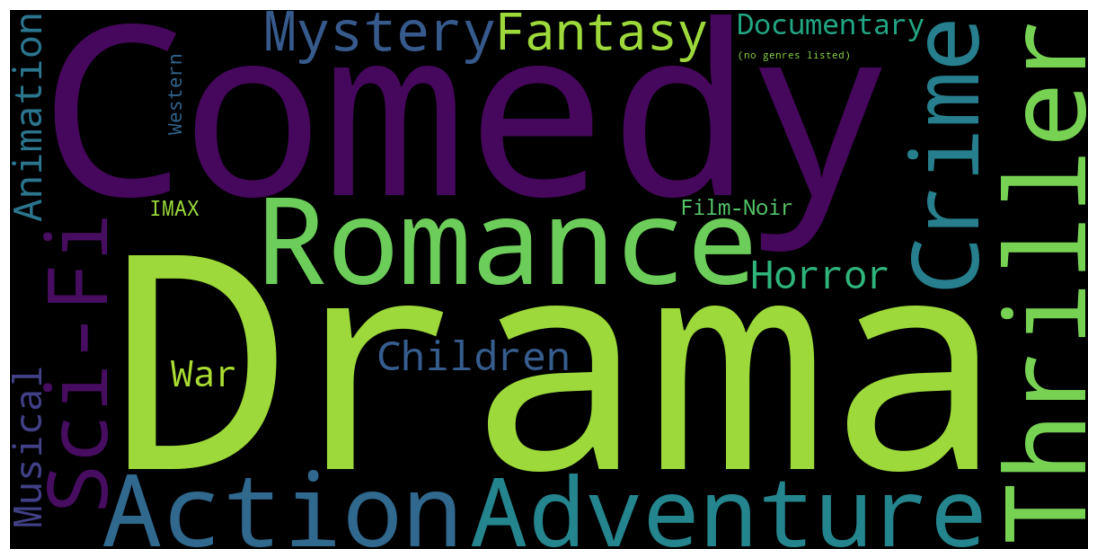

In [30]:

# 4. Generate and display WordCloud
wc = WordCloud(width=1200, height=600, background_color='black')
wc.generate_from_frequencies(genre_dict)

plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()